In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, classification_report

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading the dataset

In [3]:
def load_file(relativeFilePath: str):
    current_dir = os.getcwd()
    base_path = os.path.dirname(current_dir)
    print(base_path)
    completePath = os.path.join(base_path, relativeFilePath)
    return completePath

print(load_file(r"MLOps\Assignment-data-diabetes.csv"))

c:\Users\lakshya.vashisth\Documents\git repos\Assignments
c:\Users\lakshya.vashisth\Documents\git repos\Assignments\MLOps\Assignment-data-diabetes.csv


In [4]:
dataset = pd.read_csv(load_file(r"MLOps\Assignment-data-diabetes.csv"))
dataset.head()

c:\Users\lakshya.vashisth\Documents\git repos\Assignments


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Checking the shape and information of Dataframe

In [5]:
# Check the shape of the dataset
print("Size of the dataset:", dataset.shape)
print ("Number of rows: {}" . format (dataset.shape [0]))
print ("Number of columns: {}" . format (dataset.shape [1]))

Size of the dataset: (768, 9)
Number of rows: 768
Number of columns: 9


In [6]:
dataset.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# Check missing values in the dataset
missing_values = dataset.isnull().sum()
print("Missing Values per column:")
print(missing_values)

Missing Values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


As we can see there are no missing or null values in the data set, Lets try to visulaize the features of the dataset to understand the distribution

In [8]:
# Check duplicate 
print ("Dataframe has :" , dataset.duplicated().sum(), "duplicate values")


Dataframe has : 0 duplicate values


### Visualization

<Axes: title={'center': 'Correlation Graph'}>

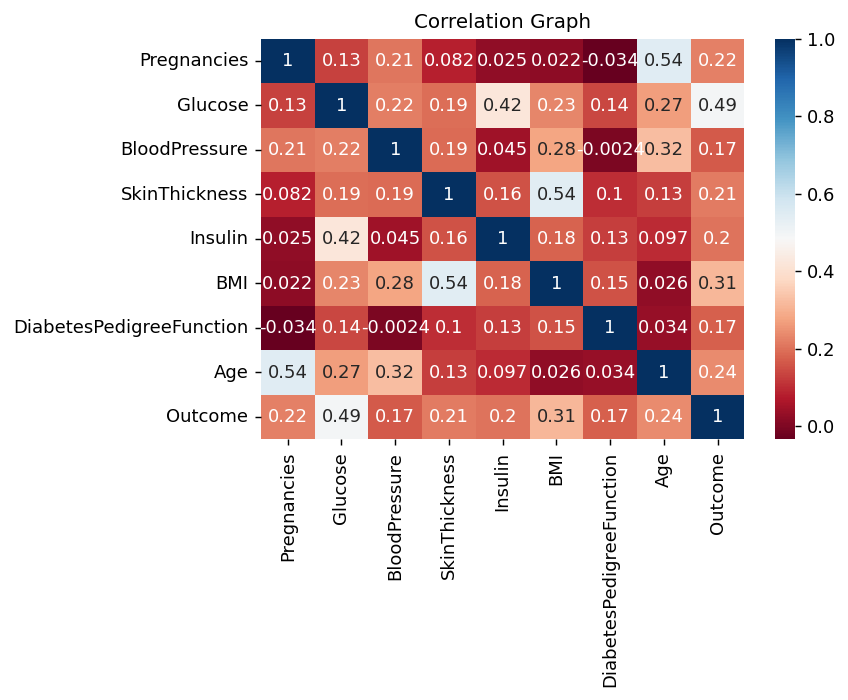

In [30]:
plt.figure (figsize = [6,4],  dpi = 130 )
plt.title ("Correlation Graph" , fontsize = 11 )
sns.heatmap (dataset.corr(), annot = True , cmap="RdBu" )

In [31]:
# Plot histograms to understand the feature distributions
def plotHistograms(data, columns=None, figsize=(15, 10), bins=30, kde=True, color_palette='Set2'):
    
    # If no columns specified, use all numeric columns
    if columns is None:
        columns = data.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove non-numeric columns if any were specified
    numeric_columns = [col for col in columns if col in data.select_dtypes(include=[np.number]).columns]
    
    if not numeric_columns:
        print("No numeric columns found to plot!")
        return None, None
    
    # calculate dimension for subplot
    n_cols = len(numeric_columns)
    n_rows = (n_cols + 2) // 3  
    
    # Create subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=figsize)
    
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()
    
    # Set color palette
    colors = sns.color_palette(color_palette, n_cols)
    
    # Plot histograms for each column
    for i, column in enumerate(numeric_columns):
        sns.histplot(data[column], kde=kde, ax=axes_flat[i], bins=bins, color=colors[i])
        axes_flat[i].set_xlabel('Values')
        axes_flat[i].set_ylabel('Density' if kde else 'Frequency')
        axes_flat[i].set_title(f'Distribution of {column}')
        axes_flat[i].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

Plotting raw features:


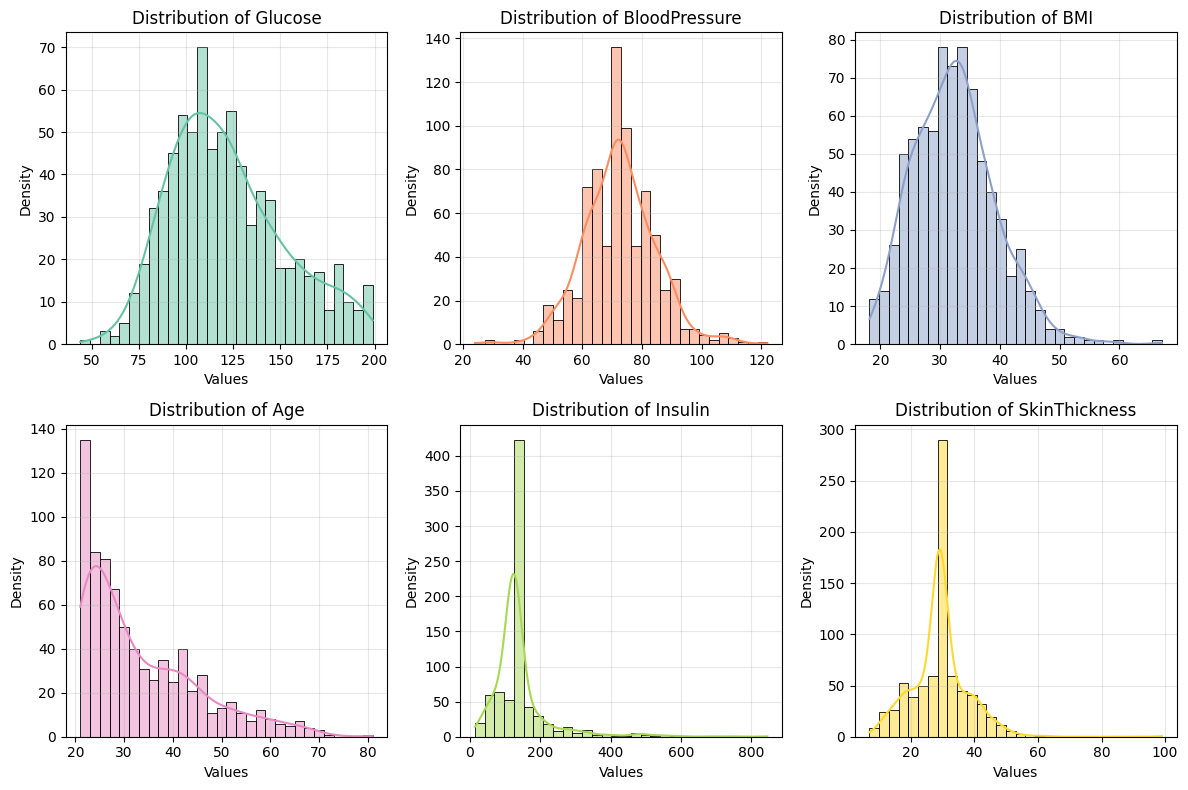

In [32]:
# Ploting Histogram for specific columns to see the feature distribution
print("Plotting raw features:")
selected_columns = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin', 'SkinThickness']
fig, axes = plotHistograms(dataset, columns=selected_columns, figsize=(12, 8))

The above histograms shows 0 as values for Glucose, Blood Pressure, BMI, etc.. Which is not medically correct. So we need to handle these values

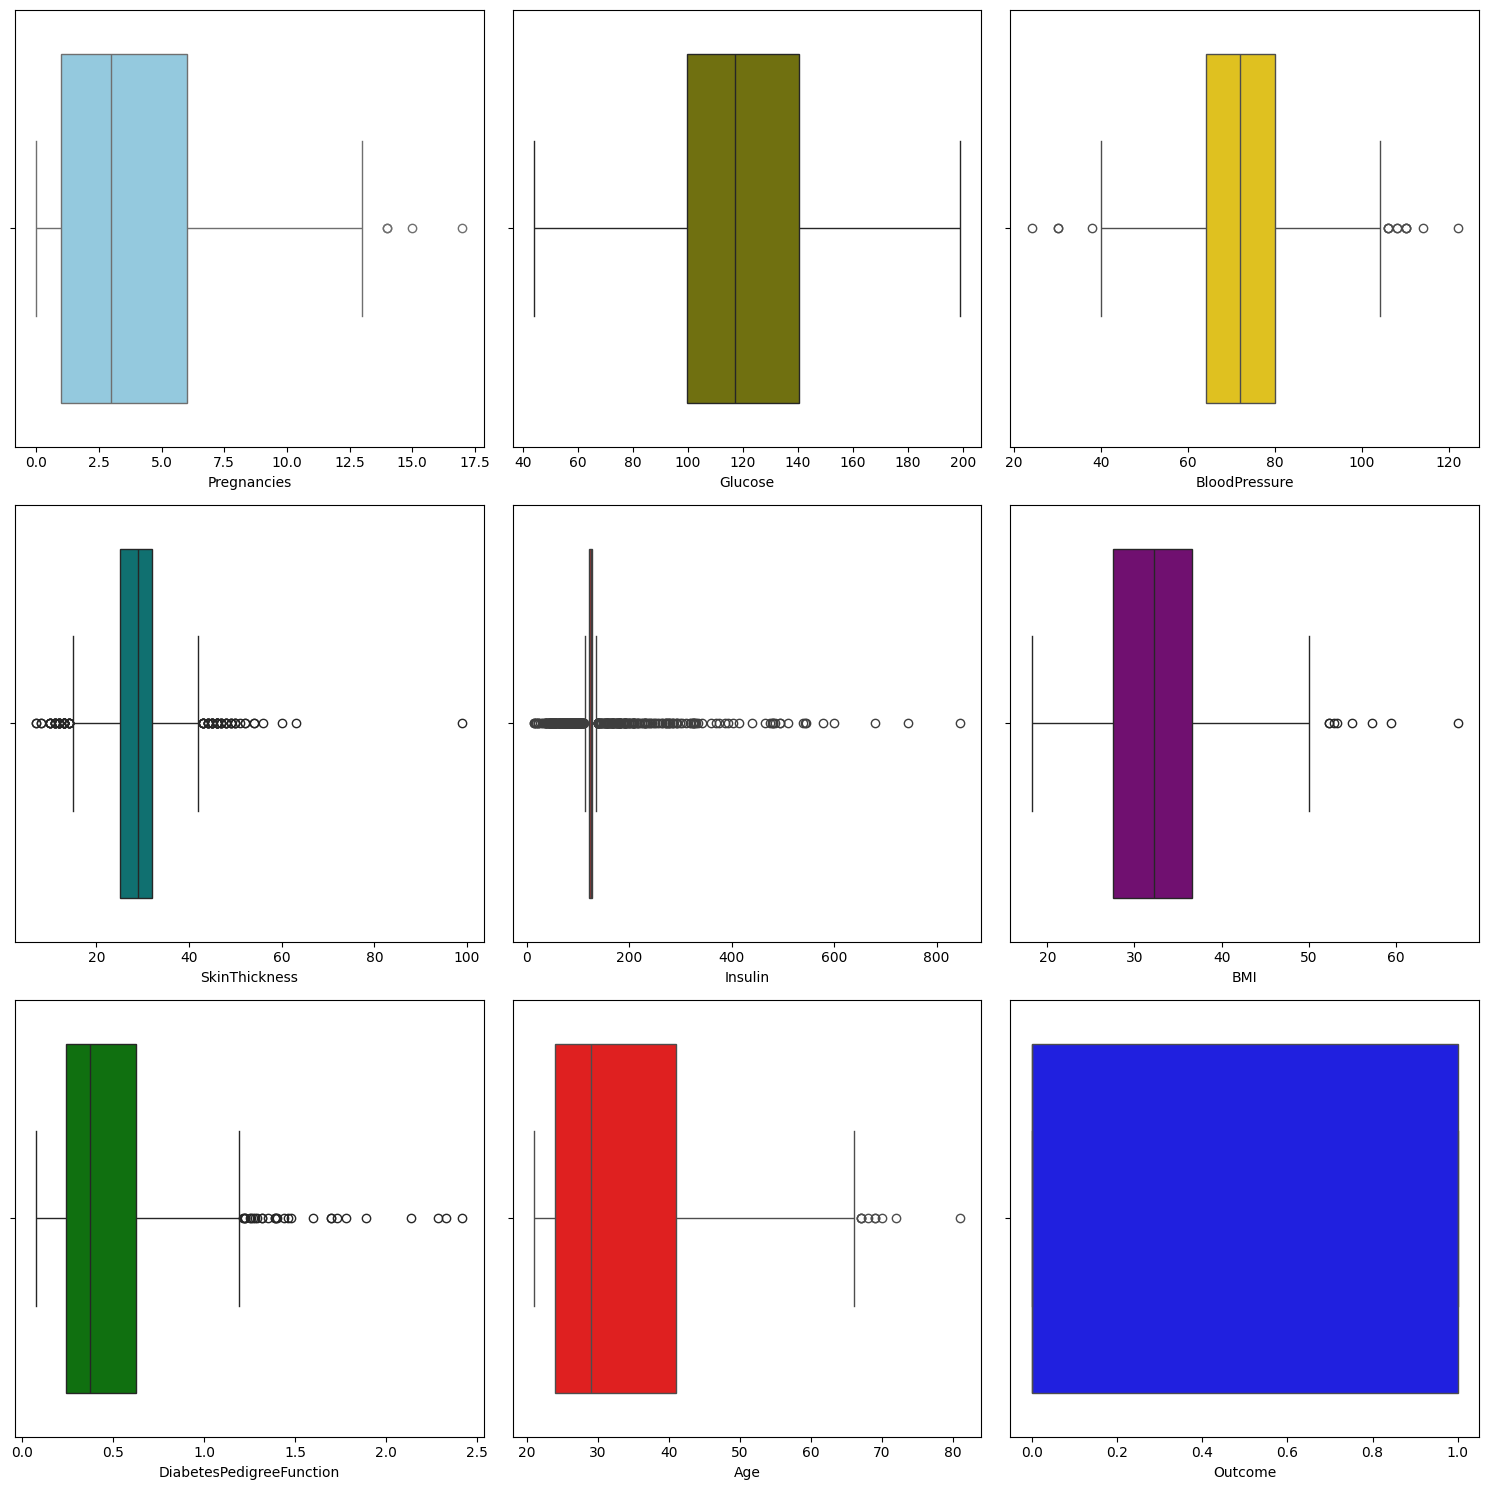

In [33]:
lst1=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
lst_col=['skyblue','olive','gold','teal','brown','purple','green','red','blue']
f, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False) # Set up the matplotlib figure
axes = axes.flatten()  # Plot a simple histogram with binsize determined automatically
for ax,k,m in zip(axes,lst1,lst_col):
    sns.boxplot(data=dataset, x=k, color=m, ax=ax)
plt.tight_layout()  
plt.show()

As per the box plot visualizations, there are presence of outliers in the dataset, which may cause issues to the 

In [34]:
zero_features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',"Insulin",'BMI']
total_count = dataset['Glucose'].count()

for feature in zero_features:
    zero_count = dataset[dataset[feature]==0][feature].count()
    print('{0} 0 number of cases {1}, percent is {2:.2f} %'.format(feature, zero_count, 100*zero_count/total_count))

Pregnancies 0 number of cases 111, percent is 14.45 %
Glucose 0 number of cases 0, percent is 0.00 %
BloodPressure 0 number of cases 0, percent is 0.00 %
SkinThickness 0 number of cases 0, percent is 0.00 %
Insulin 0 number of cases 0, percent is 0.00 %
BMI 0 number of cases 0, percent is 0.00 %


In [35]:
# Impute features that cannot be 0, medically not correct
import numpy as np
imputed_df = dataset
lst=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for i in lst:
    imputed_df[i].replace(0, np.nan, inplace=True)
    imputed_df[i].fillna(imputed_df[i].median(), inplace=True)
imputed_df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Plotting imputed features:


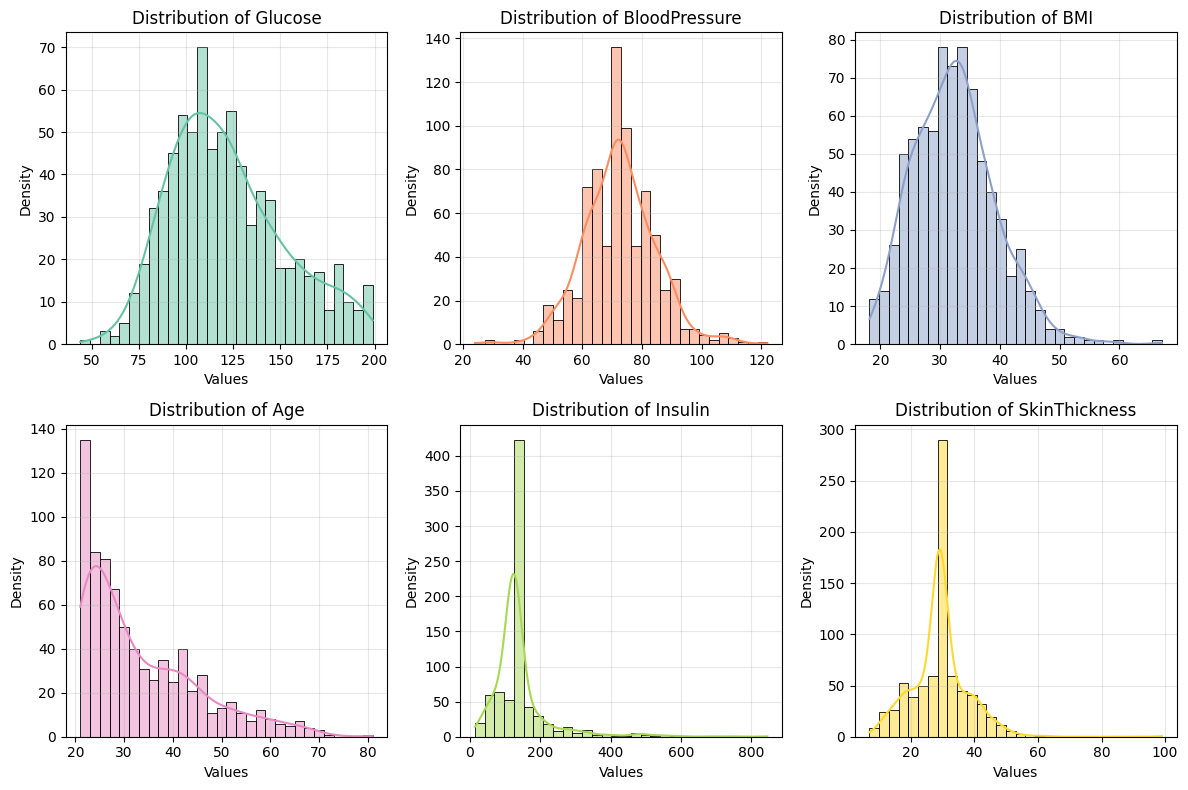

In [36]:
# Now visualizing the distribution after imputing the features
print("Plotting imputed features:")
selected_columns = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin', 'SkinThickness']
fig, axes = plotHistograms(imputed_df, columns=selected_columns, figsize=(12, 8))

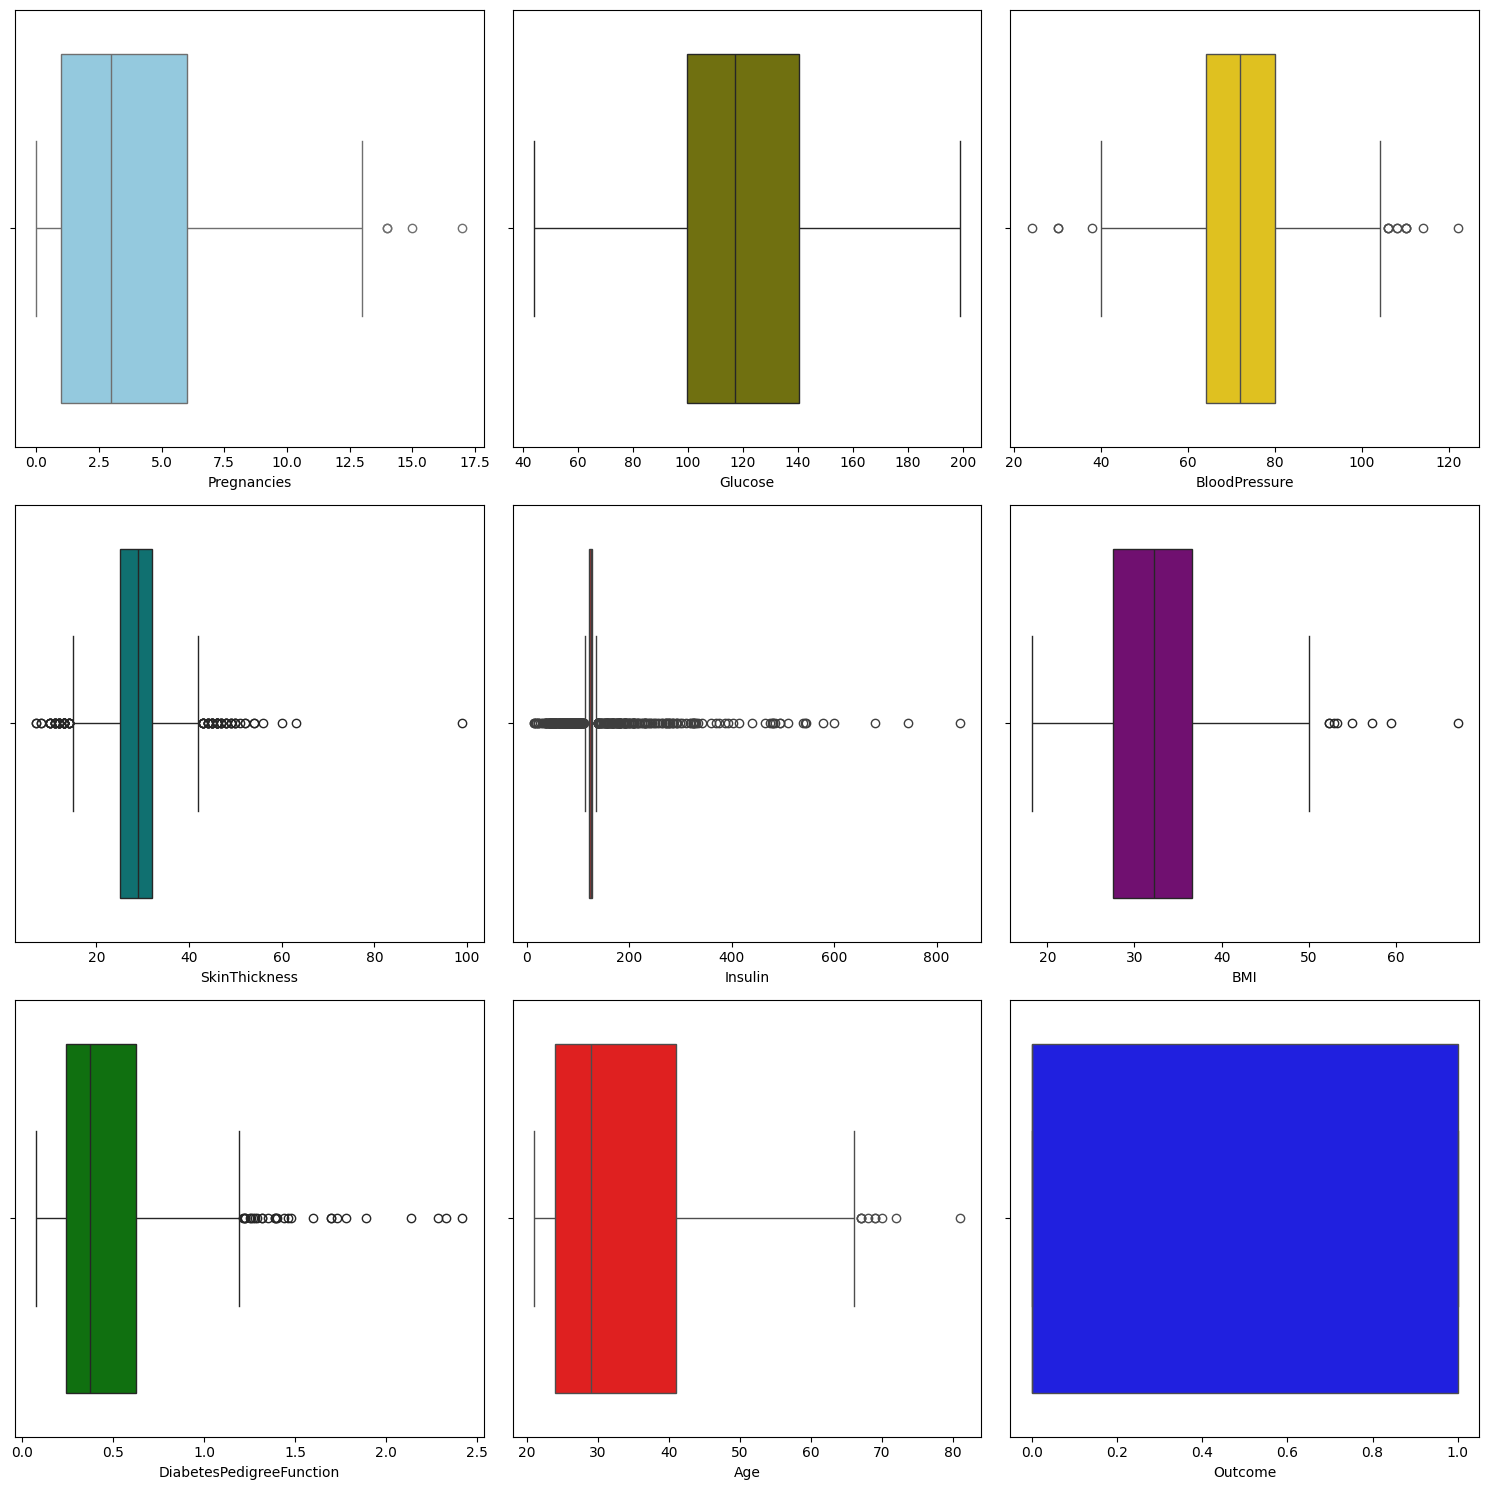

In [37]:
lst1=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
lst_col=['skyblue','olive','gold','teal','brown','purple','green','red','blue']
f, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False) # Set up the matplotlib figure
axes = axes.flatten()  # Plot a simple histogram with binsize determined automatically
for ax,k,m in zip(axes,lst1,lst_col):
    sns.boxplot(data=imputed_df, x=k, color=m, ax=ax)
plt.tight_layout()  
plt.show()

### Split the dataset and Target variable for both imputed 

In [17]:
imputed_y = imputed_df['Outcome']
imputed_X = imputed_df.drop('Outcome', axis=1 )

raw_y = dataset['Outcome']
raw_X = dataset.drop('Outcome', axis=1)

In [18]:
# Function for Scaling features using MinMax scaling
def MinMaxScaling(data):
    scaler = MinMaxScaler()
    return scaler.fit_transform(data)

Splitting the train and test sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(imputed_X, imputed_y, test_size=0.2, random_state=42, stratify=imputed_y)

raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(raw_X, raw_y, test_size=0.2, random_state=42, stratify=raw_y)

In [20]:
X_train_scaled = MinMaxScaling(X_train)
X_test_scaled = MinMaxScaling(X_test)

### Model Training

In [21]:
processed_model = RandomForestClassifier()
processed_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
raw_model = RandomForestClassifier()
raw_model.fit(raw_X_train, raw_y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
processed_y_predict = processed_model.predict(X_test_scaled)

raw_y_predict = raw_model.predict(raw_X_test)

In [24]:
# calculate the accuracy and F1 scores for both the model outputs

accuracy_processed = accuracy_score(y_test, processed_y_predict)
accuracy_raw = accuracy_score(raw_y_test, raw_y_predict)

print(f'Accuracy of Processed dataset: {accuracy_processed:.4f}')
print(f'Accuracy of Raw dataset: {accuracy_raw:.4f}')


Accuracy of Processed dataset: 0.7403
Accuracy of Raw dataset: 0.7143


In [25]:
# Detailed Classification Reports
print("Raw Data Model - Classification Report:")
print("=" * 50)
print(classification_report(raw_y_test, raw_y_predict, target_names=['No Diabetes', 'Diabetes']))

print("\nPreprocessed Data Model - Classification Report:")
print("=" * 50)
print(classification_report(y_test, processed_y_predict, target_names=['No Diabetes', 'Diabetes']))

Raw Data Model - Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.83      0.79       100
    Diabetes       0.61      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Preprocessed Data Model - Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.80      0.80       100
    Diabetes       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



From the above classification report, we can clearly say that the model with Preprocessed data has shown improved accuracy over the model fed with Raw data.

Key Findings
- Data Quality Impact: Preprocessing eliminates medically impossible zero values in Glucose, BloodPressure, and BMI
- Feature Scaling: MinMax scaling ensures equal feature contribution
- Model Learning: Cleaner data leads to better pattern recognition

### Q What Would Go Wrong in the Machine Learning Lifecycle if Preprocessing is Skipped?

-- Preprocessing is a crucial step when working on Machine learning tasks, data rules the model's capacity to interpret the pattern and result in better prediction.

It follows by the saying "Garbage In, Garbage Out" which basically means if you input garbage data (i.e, without preprocessing) will result in Garbage output in term of prediction that may not be useful.

- One problem I faced while training the model with Raw data is that the model was not able to learn the pattern in Logistic regression in default iteration as the data was not Normalized on a particular scale and some features had large variations. So I increased the max_iterations to 200. Later I Used Random forest classifier which gives better result due to it's sensitivity to outliers.

- If the Data is not preprocessed, then the model may learn incorrect pattern, as a example in the Diabetes dataset as we had seen that value of 'Glucose', 'BloodPressure', 'BMI', etc. features were 0 for most samples, which is not medically correct. Hence the model may learn incorrect pattern and may produce misleading evaluation and result.

### Q Now, based on your own coding experience (in this lab or elsewhere), explain whether this problem could have been identified or prevented using only normal programming practices. Justify with one concrete example from your own implementation or learning

-- Yes, many of these preprocessing problems could have been identified and prevented using normal programming practices, but not all of them.

Most of the calculative things can be identified and prevented, but when comes to Domain knowledge requirements then these things can not be prevented using standard coding practices. Like - Understanding that the Glucose, BMI etc. features can not be 0. These are either missing readings or corrupted values.
Also, Knowing which value combinations are medically impossible requires subject matter expertise.

**Example:**

• In my zero values analysis, I manually checked for zero counts in medical features, but this could have been automated as a standard validation step

• My histogram plotting function revealed the zero value problem visually, but I could have enhanced it to automatically flag and report suspicious distributions

• The data loading function could have included medical data validation rules that would have caught these issues immediately